In [43]:
# Librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from collections import Counter
import os
from sklearn.neighbors import LocalOutlierFactor
import tensorflow as tf
from sklearn.model_selection import train_test_split
import matplotlib.patheffects as path_effects



In [78]:
# Funciones utilizadas

def graficar_histograma(poblacion, color="deepskyblue", labelx="E",bins_auto=True,figsize=(10,6),savefig=False,filename="histograma.png"):
    """
    Genera un histograma de la población, mostrando la media con línea vertical.

    Parámetros
    ----------
    poblacion : array-like
        Datos numéricos (ej. distancias promedio).
    color : str, opcional
        Color de las barras del histograma.
    bins_auto : bool, opcional
        Si True, calcula los bins con la regla de Sturges (sqrt(n)),
        si False, deja que matplotlib decida.
    figsize : tuple, opcional
        Tamaño de la figura (ancho, alto).
    savefig : bool, opcional
        Si True, guarda la figura como archivo PNG.
    filename : str, opcional
        Nombre del archivo donde se guardará la figura.
    """

    poblacion = np.array(poblacion)

    media = np.mean(poblacion)
    desviacion = np.std(poblacion)
    rango = np.max(poblacion) - np.min(poblacion)

    if bins_auto:
        k = int(np.sqrt(len(poblacion)))  # número de intervalos
        h = rango / k if k > 0 else 1
        bins = np.arange(np.min(poblacion), np.max(poblacion) + h, h)
    else:
        bins = "auto"

    print(f"Media: {media:.4f}")
    print(f"Desviación estándar: {desviacion:.4f}")

    plt.figure(figsize=figsize)
    plt.hist(poblacion, bins=bins, color=color, alpha=0.6,
             label="Datos", edgecolor="black")
    plt.axvline(media, color="red", label=f"$\\mu$={media:.4f}")
    plt.legend()
    plt.xlabel(labelx)
    plt.ylabel("Frecuencia")
    if savefig:
        plt.savefig(filename, bbox_inches='tight', pad_inches=0.03)
        

    plt.show()

def graficar_dispersion_umbral(df_norm, dfNombresplanetas, columna,
                               umbral=0.25, color="red",
                               figsize=(10,6),
                               savefig=False,
                               filename="dispersion.png",):
    """
    Genera una gráfica de dispersión de una columna con un umbral,
    mostrando los puntos filtrados y sus etiquetas.

    Parámetros
    ----------
    df_norm : DataFrame
        DataFrame con los datos normalizados.
    dfNombresplanetas : Series o array-like
        Nombres asociados a cada fila (ej. nombres de planetas).
    columna : str
        Nombre de la columna a graficar.
    umbral : float, opcional
        Valor mínimo para filtrar los datos.
    color : str, opcional
        Color de los puntos.
    figsize : tuple, opcional
        Tamaño de la figura.
    savefig : bool, opcional
        Si True, guarda las figuras como archivos PNG.
    filename : str, opcional
        Nombre del archivo donde se guardará la figura.
    """

    # Datos
    y = df_norm[columna]
    x = range(len(y))

    # Filtrado
    y_filter = y[y > umbral]
    x_filter = range(len(y_filter))

    print(f"Columna: {columna}")
    print(f"Cantidad total: {len(y)}")
    print(f"Cantidad > umbral ({umbral}): {len(y_filter)}")

    # -------- Gráfica general --------
    plt.figure(figsize=figsize)
    plt.scatter(x, y.values, color=color, alpha=0.2)
    plt.axhline(y=umbral, color='black', linestyle='--')
    plt.ylabel(columna)

    if savefig:
        plt.savefig(f"{filename}_general.png", bbox_inches='tight', pad_inches=0)

    plt.show()

    # Mostrar nombres filtrados
    nombres_filtrados = dfNombresplanetas[y_filter.index]
    print("\nElementos que superan el umbral:")
    print(nombres_filtrados)

    # -------- Gráfica filtrada --------
    plt.figure(figsize=figsize)
    plt.scatter(x_filter, y_filter.values, color=color)

    # Etiquetas
    for i, txt in enumerate(nombres_filtrados):
        plt.annotate(txt, (x_filter[i], y_filter.values[i]), rotation=15)

    plt.ylabel(columna)

    if savefig:
        plt.savefig(filename, bbox_inches='tight', pad_inches=0.03)

    plt.show()


# Base de datos y preprocesamiento

Se importan el conjunto de datos proveniente de [https://exoplanetarchive.ipac.caltech.edu/docs/data.html ](https://exoplanetarchive.ipac.caltech.edu/docs/data.html). En dicha liga nos dirigimos a "planetary systems" y se filtran aquellos datos que no cuenten con información de: 

1. periodo orbital (pl_orbper)
2. radio planetario (pl_rade)
3. excentricidad (pl_orbeccen)
4. temperatura en equilibrio (pl_eqt)
5. masa estelar (st_mass)
6. gravedad estelar en superficie (st_logg)
7. distancia a la estrella (sy_dist)


In [45]:
# Cargar el dataset
df=pd.read_csv("exoplanetas.csv",comment="#")
df.head()

,loc_rowid,pl_name,pl_orbper,pl_rade,pl_masse,pl_orbeccen,pl_eqt,st_mass,st_metratio,st_logg,sy_dist
0,1,11 Com b,323.21000,NaN,NaN,0.238,NaN,2.09,[Fe/H],2.45,93.1846
1,2,11 Com b,326.03000,NaN,NaN,0.231,NaN,2.70,[Fe/H],2.31,93.1846
2,3,11 Com b,NaN,NaN,NaN,NaN,NaN,2.60,NaN,NaN,93.1846
3,4,11 UMi b,516.22000,NaN,NaN,0.080,NaN,1.80,[Fe/H],1.60,125.3210
4,5,11 UMi b,516.21997,NaN,NaN,0.080,NaN,2.78,[Fe/H],1.93,125.3210


In [46]:
# Retirar columnas 
df = df.drop('pl_masse', axis=1)
df = df.drop('st_metratio', axis=1)


In [47]:
#Revisar si hay columnas con datos nulos
df.isna().sum()


loc_rowid          0
pl_name            0
pl_orbper       3271
pl_rade        12130
pl_orbeccen    20404
pl_eqt         21971
st_mass         6038
st_logg         8705
sy_dist          844
dtype: int64

In [48]:
# Eliminamos datos nulos
df_clean = df.dropna()
len(df_clean)
print("Numero de planetas en el dataset limpio: ", len(df_clean))


Numero de planetas en el dataset limpio:  14037


In [49]:
# Obtenemos el nombre de los planetas y los datos en dataframes separados
dfNombresplanetas=df_clean['pl_name']
# Dataframe numerico
df_clean = df_clean.drop(['pl_name',"loc_rowid"], axis=1)
df_clean
# Normalizamos los datos
df_norm=(df_clean - df_clean.min()) / (df_clean.max() - df_clean.min())
df_norm

,pl_orbper,pl_rade,pl_orbeccen,pl_eqt,st_mass,st_logg,sy_dist
110,0.000153,0.000423,0.066304,0.467047,0.232672,0.428029,0.001753
177,0.002270,0.000861,0.006272,0.121086,0.119068,0.420436,0.000924
188,0.005118,0.000526,0.003674,0.085165,0.119068,0.420436,0.000924
208,0.011372,0.000458,0.000000,0.107329,0.248778,0.436283,0.050067
233,0.001126,0.004978,0.071739,0.478002,0.377912,0.328986,0.168760
...,...,...,...,...,...,...,...
38958,0.001098,0.002921,0.000000,0.281584,0.271498,0.411522,0.078078
38972,0.000982,0.005355,0.000000,0.369984,0.395168,0.360350,0.066285
38976,0.000735,0.003530,0.041304,0.412274,0.376474,0.394355,0.065900
39066,0.001668,0.000418,0.000000,0.260439,0.265746,0.413173,0.003399


# Análisis exploratorio

In [50]:
# Configurando lista de colores para los histogramas
colores=['red','deepskyblue','lime','yellow','orange','purple','pink']
# Creando carpeta para guardar las imagenes

if not os.path.exists("Imagenes"):
    os.makedirs("Imagenes")
if not os.path.exists("Imagenes/Histogramas"):
    os.makedirs("Imagenes/Histogramas")
if not os.path.exists("Imagenes/Dispersion"):
    os.makedirs("Imagenes/Dispersion")
if not os.path.exists("Imagenes/ReduccionDimensional"):
    os.makedirs("Imagenes/ReduccionDimensional")


Media: 0.0071
Desviación estándar: 0.0169


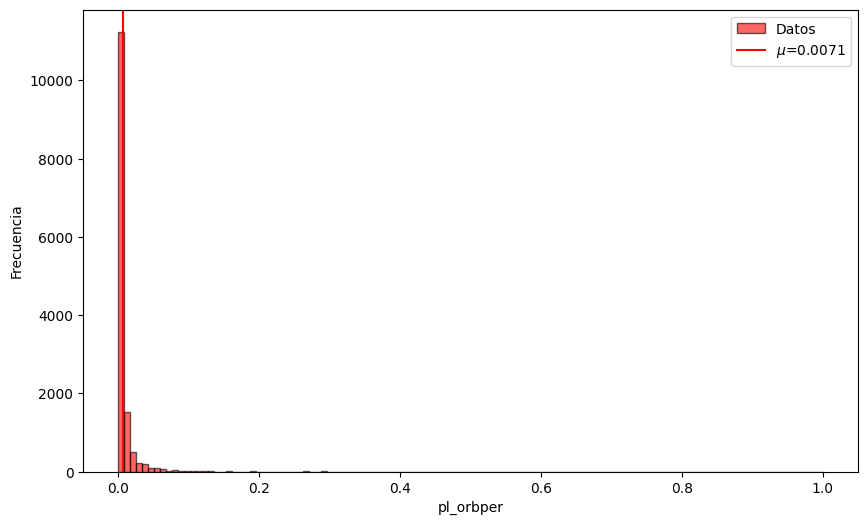

Media: 0.0013
Desviación estándar: 0.0215


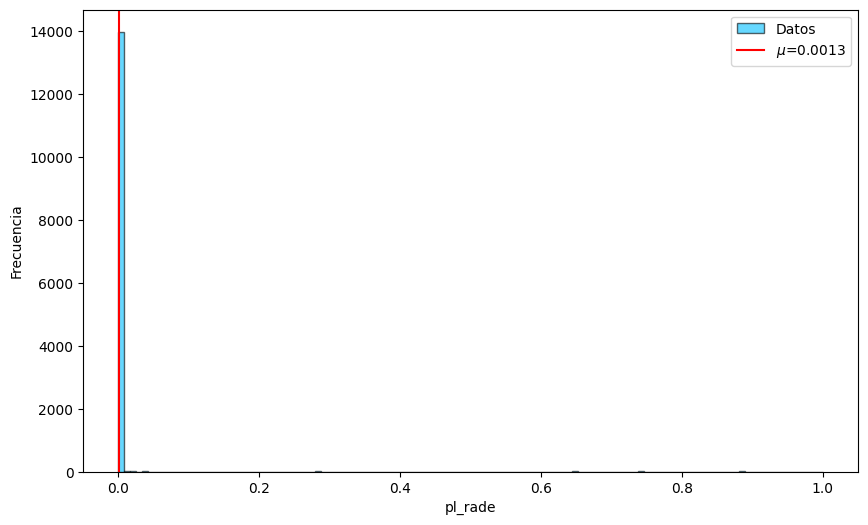

Media: 0.0093
Desviación estándar: 0.0536


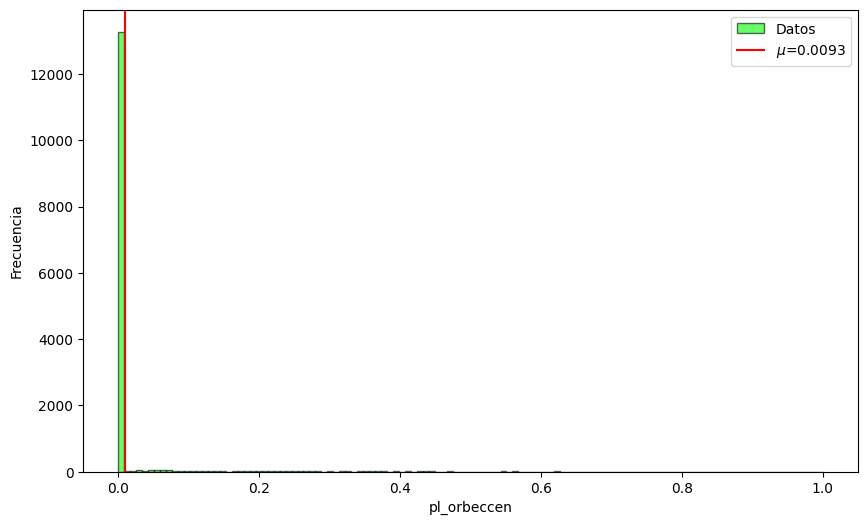

Media: 0.1869
Desviación estándar: 0.1016


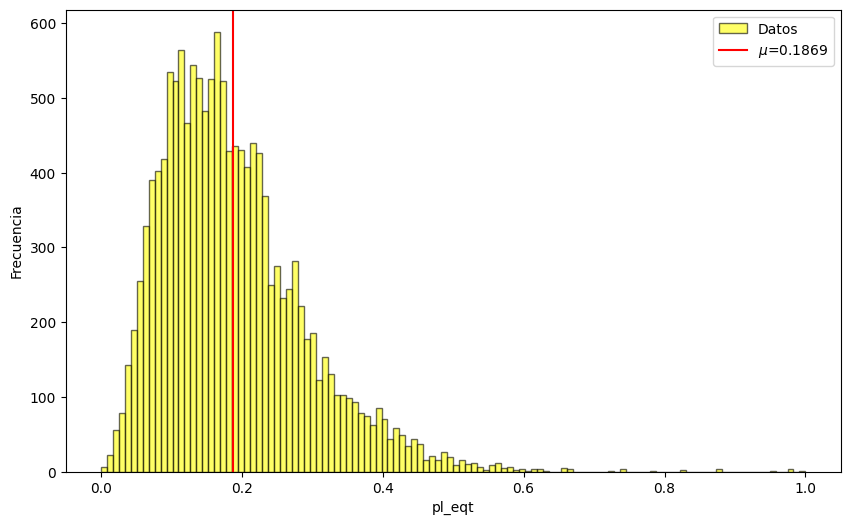

Media: 0.2423
Desviación estándar: 0.0632


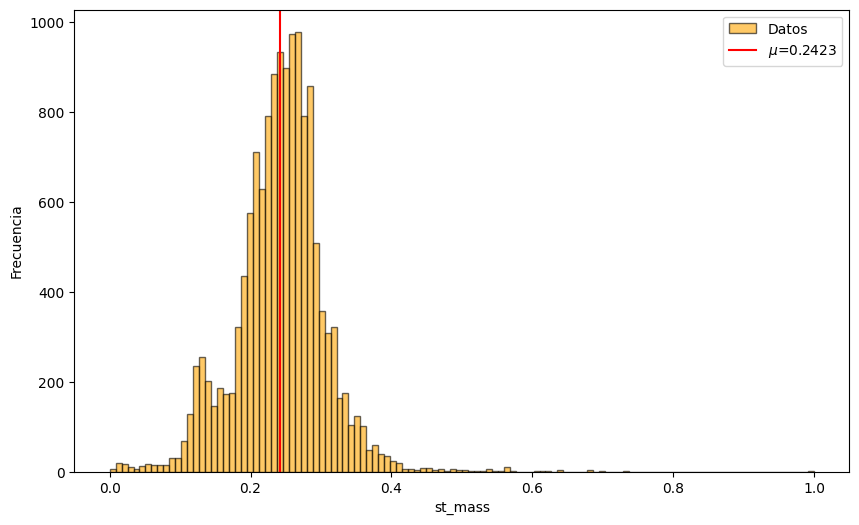

Media: 0.4266
Desviación estándar: 0.0368


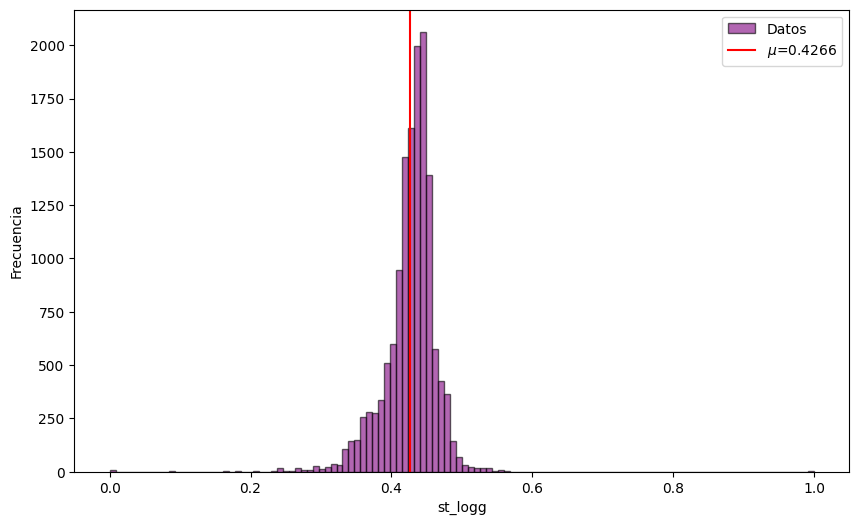

Media: 0.2208
Desviación estándar: 0.1334


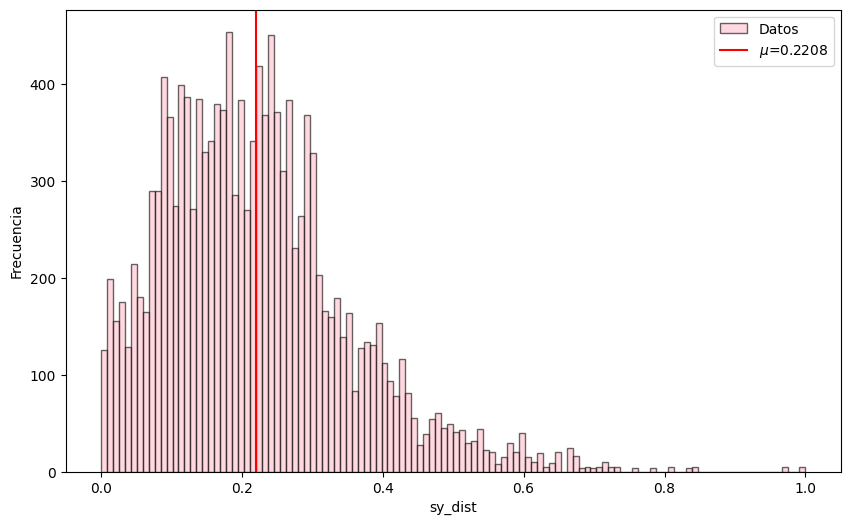

Media: 0.0979
Desviación estándar: 0.0625


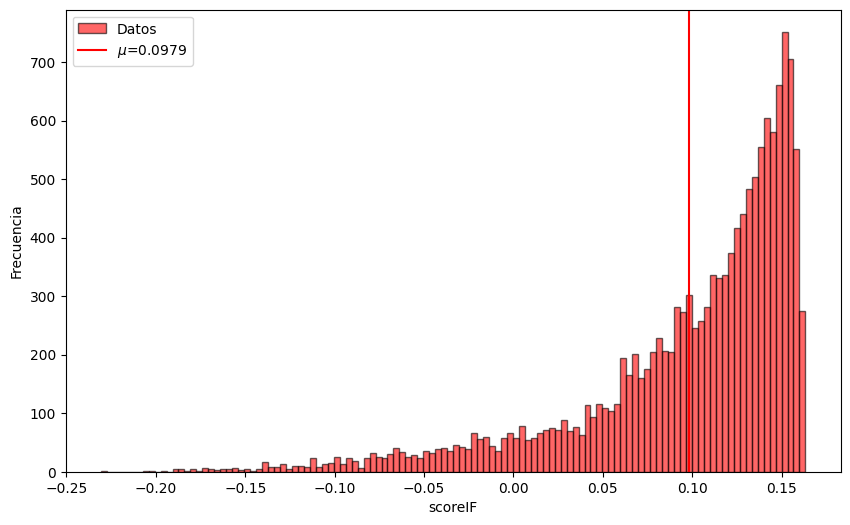

Media: 0.8186
Desviación estándar: 0.5743


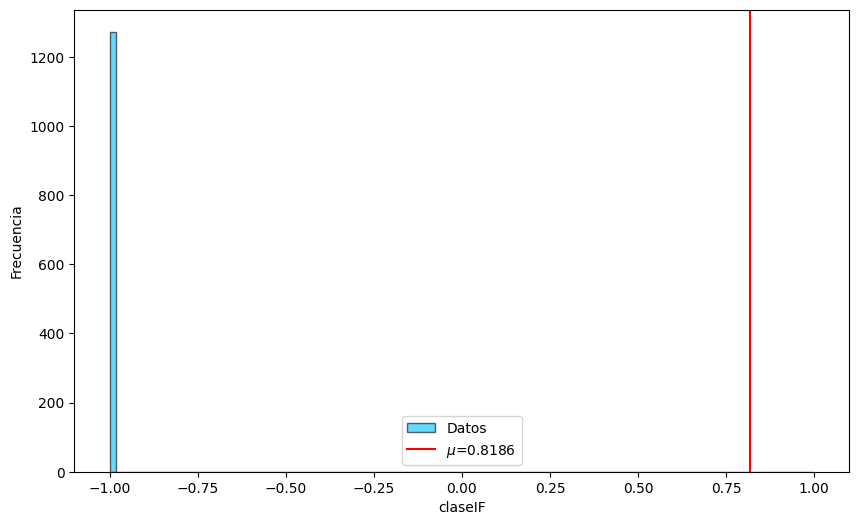

Media: 0.9581
Desviación estándar: 0.2864


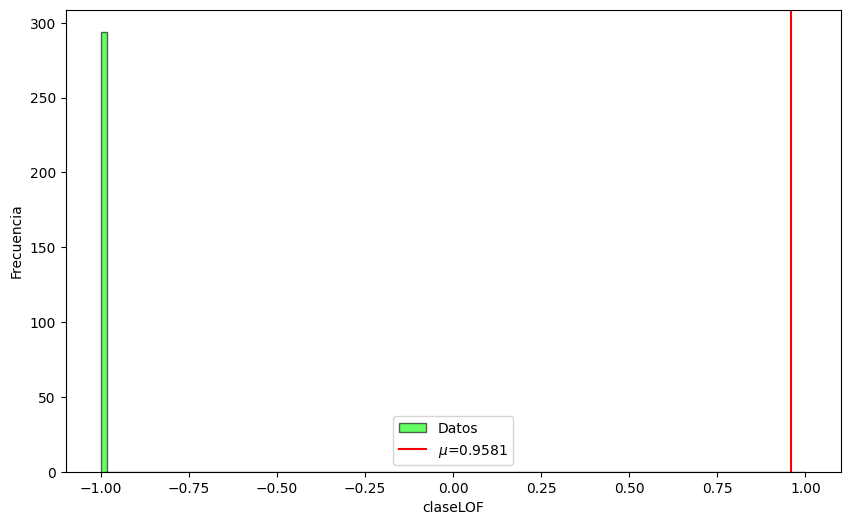

Media: -1.0842
Desviación estándar: 0.3078


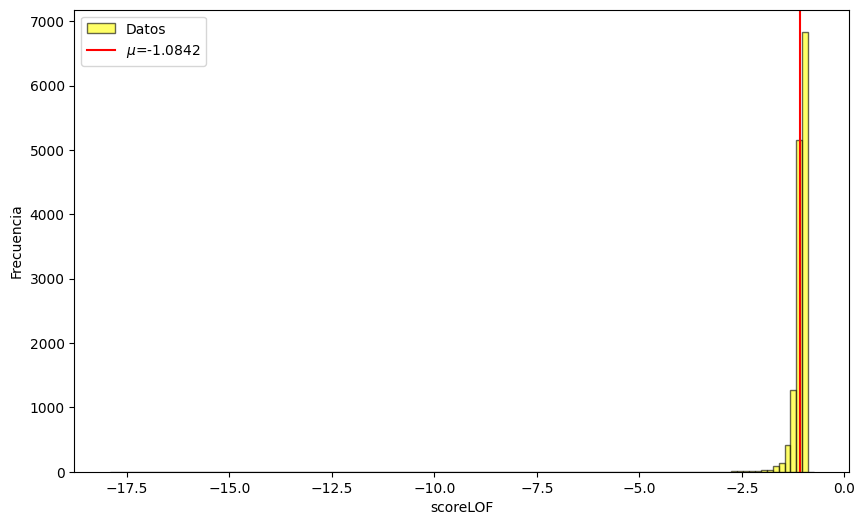

In [79]:
# Generando histogramas para cada variable
for i, columna in enumerate(df_norm.columns):
    graficar_histograma(df_norm[columna], color=colores[i % len(colores)], labelx=columna,savefig=True,filename=f"Imagenes/Histogramas/histograma_{columna}.png")
    

In [52]:
df_norm.columns

Index(['pl_orbper', 'pl_rade', 'pl_orbeccen', 'pl_eqt', 'st_mass', 'st_logg',
       'sy_dist'],
      dtype='object')

In [53]:
dfNombresplanetas[dfNombresplanetas.str.contains("Kepler-167 e")]

15901    Kepler-167 e
15902    Kepler-167 e
15905    Kepler-167 e
15907    Kepler-167 e
15908    Kepler-167 e
15909    Kepler-167 e
Name: pl_name, dtype: object

Columna: pl_orbper
Cantidad total: 14037
Cantidad > umbral (0.25): 10


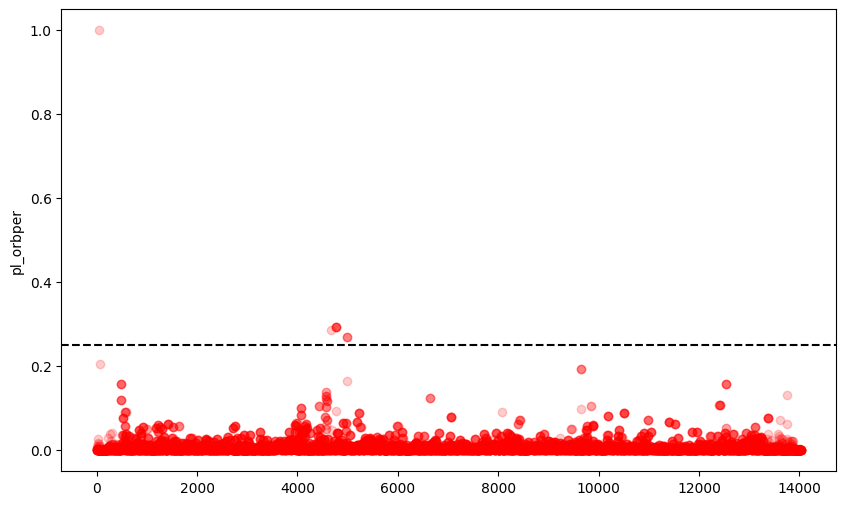


Elementos que superan el umbral:
529      EPIC 248847494 b
15709       Kepler-1654 b
15902        Kepler-167 e
15905        Kepler-167 e
15907        Kepler-167 e
15908        Kepler-167 e
15909        Kepler-167 e
16297       Kepler-1704 b
16299       Kepler-1704 b
16300       Kepler-1704 b
Name: pl_name, dtype: object


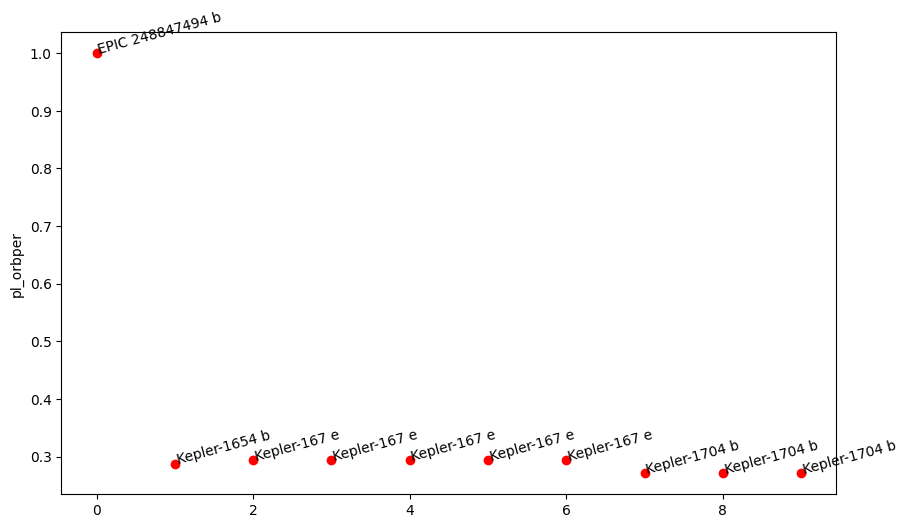

Columna: pl_rade
Cantidad total: 14037
Cantidad > umbral (0.2): 13


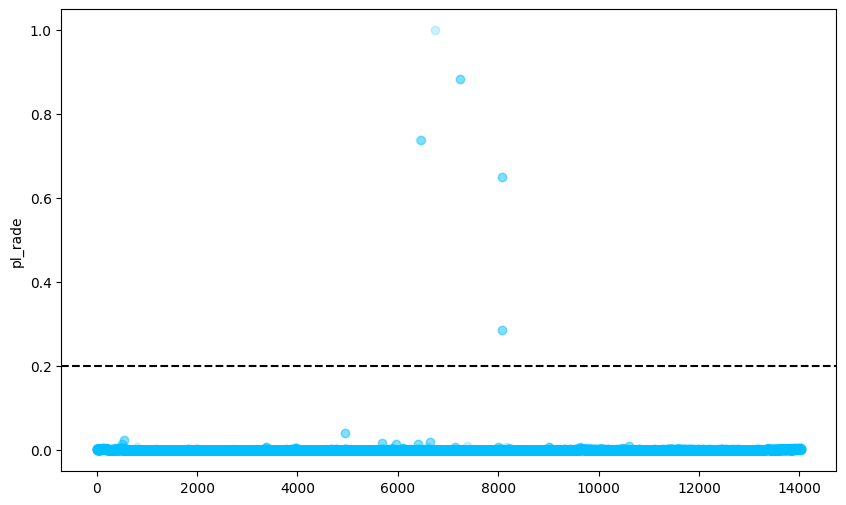


Elementos que superan el umbral:
19036    Kepler-1946 b
19037    Kepler-1946 b
19041    Kepler-1946 b
19592    Kepler-1999 b
20775     Kepler-230 b
20779     Kepler-230 b
20781     Kepler-230 b
22874      Kepler-29 b
22875      Kepler-29 b
22876      Kepler-29 b
22885      Kepler-29 c
22889      Kepler-29 c
22894      Kepler-29 c
Name: pl_name, dtype: object


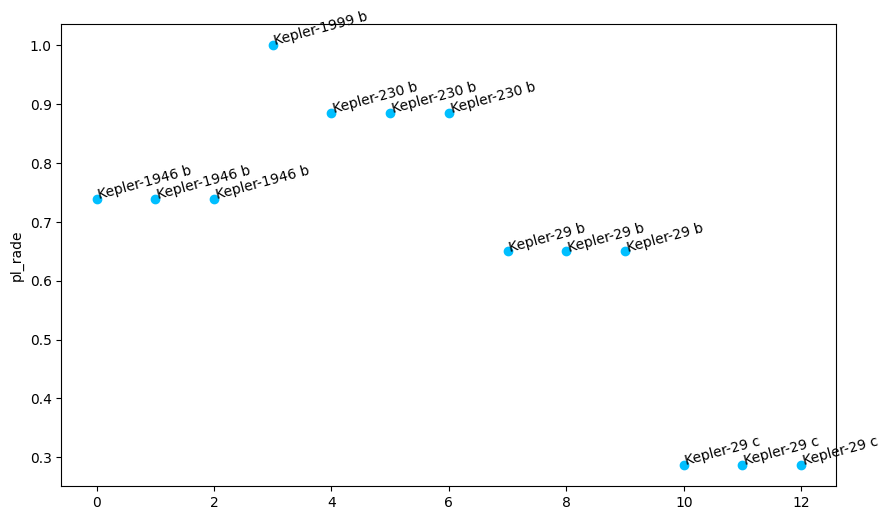

Columna: pl_orbeccen
Cantidad total: 14037
Cantidad > umbral (0.8): 5


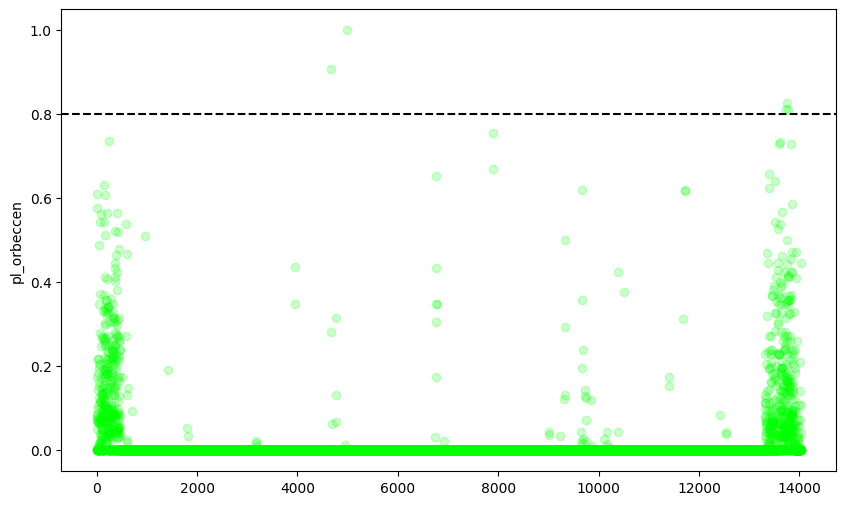


Elementos que superan el umbral:
15724    Kepler-1656 b
16299    Kepler-1704 b
36867       TOI-4127 b
36957       TOI-4562 b
37018       TOI-5110 b
Name: pl_name, dtype: object


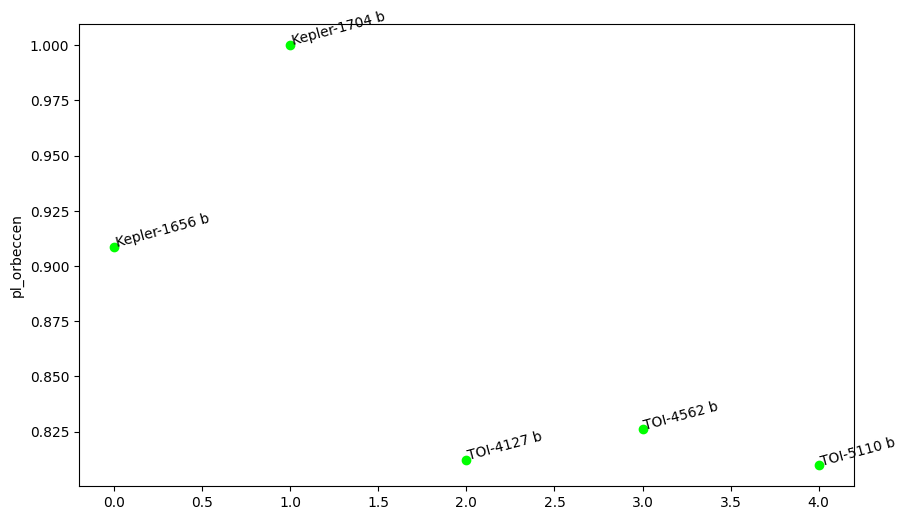

In [54]:
umbrales = [0.25, 0.2, 0.8]
columnas=['pl_orbper','pl_rade',"pl_orbeccen"]
for i, columna in enumerate(columnas):
    graficar_dispersion_umbral(
        df_norm,
        dfNombresplanetas,
        columna,
        umbral=umbrales[i],
        color=colores[i % len(colores)],
        savefig=True,
        filename=f"Imagenes/Dispersion/dispersion_{columna}.png"
    )

# Detección de anomalias


## Selección de parametros

### Isolation Forest


In [55]:
if not os.path.exists("Imagenes/DeteccionAnomalias"):
    os.makedirs("Imagenes/DeteccionAnomalias")

In [56]:
n_trees=200
list_trees=[2,5,10,25,50,100,200]
AnomaliasDetectadas=[]
X=df_norm.copy()
for n_trees in list_trees:
  print("n_trees: ",n_trees)
  clf = IsolationForest(n_estimators=n_trees, random_state=42)
  clf.fit(X)
  y_pred = clf.predict(X)

  df_norm["scoreIF"] = clf.decision_function(X)
  df_norm["claseIF"] = y_pred  # -1 = outlier, 1 = inlier
  AnomaliasDetectadas.append(len(df_norm[df_norm["claseIF"]==-1]))

n_trees:  2
n_trees:  5
n_trees:  10
n_trees:  25
n_trees:  50
n_trees:  100
n_trees:  200


Text(29.472222222222214, 0.5, 'Número de anomalias')

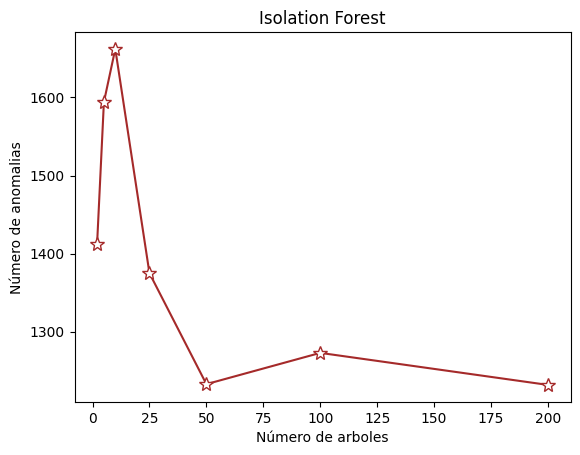

In [57]:
plt.plot(list_trees,AnomaliasDetectadas,marker="*",markerfacecolor="white",markersize=10,color="Brown")
plt.savefig("Imagenes/DeteccionAnomalias/Anomalias_vs_Trees.png")
plt.title("Isolation Forest")
plt.xlabel("Número de arboles")
plt.ylabel("Número de anomalias")

In [58]:
# Selecionamos 100 arboles para el modelo final
n_trees=100
print("n_trees: ",n_trees)

clf = IsolationForest(n_estimators=n_trees, random_state=42)
clf.fit(X)
y_pred = clf.predict(X)

df_norm["scoreIF"] = clf.decision_function(X)
df_norm["claseIF"] = y_pred  # -1 = outlier, 1 = inlier

n_trees:  100


### Local Outlier Factor (LOF)

In [59]:
vecindad=range(1,20+1)
AnomaliasDetectadas=[]
for vecinos in vecindad:
  print("vecindad: ",vecinos)
  clf = LocalOutlierFactor(n_neighbors=vecinos)
  y_pred = clf.fit_predict(X)
  #df_norm["scoreLOF"] = clf.negative_outlier_factor_
  df_norm["claseLOF"] = y_pred  # -1 = outlier, 1 = inlier
  AnomaliasDetectadas.append(len(df_norm[df_norm["claseLOF"]==-1]))

vecindad:  1
vecindad:  2
vecindad:  3
vecindad:  4
vecindad:  5
vecindad:  6
vecindad:  7
vecindad:  8
vecindad:  9
vecindad:  10
vecindad:  11
vecindad:  12
vecindad:  13
vecindad:  14
vecindad:  15
vecindad:  16
vecindad:  17
vecindad:  18
vecindad:  19
vecindad:  20


Text(0, 0.5, 'Número de anomalias')

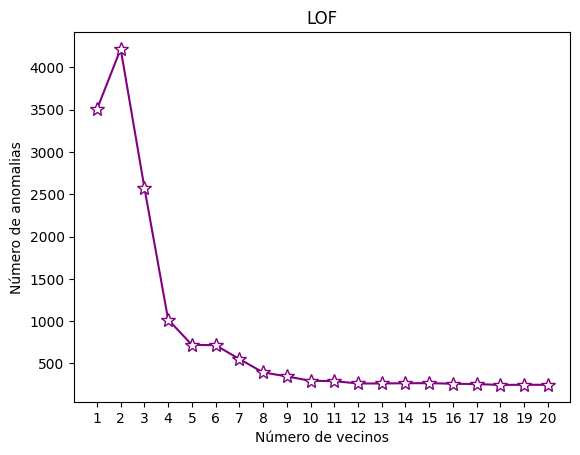

In [60]:
plt.plot(vecindad,AnomaliasDetectadas,marker="*",markerfacecolor="white",markersize=10,color="purple")
plt.title("LOF")
plt.xlabel("Número de vecinos")
plt.xticks(vecindad)
plt.ylabel("Número de anomalias")

In [61]:
#Seleccionamoso 10
vecinos=10
clf = LocalOutlierFactor(n_neighbors=vecinos)
y_pred = clf.fit_predict(X)
df_norm["scoreLOF"] = clf.negative_outlier_factor_
df_norm["claseLOF"] = y_pred  # -1 = outlier, 1 = inlier

In [62]:
X

,pl_orbper,pl_rade,pl_orbeccen,pl_eqt,st_mass,st_logg,sy_dist
110,0.000153,0.000423,0.066304,0.467047,0.232672,0.428029,0.001753
177,0.002270,0.000861,0.006272,0.121086,0.119068,0.420436,0.000924
188,0.005118,0.000526,0.003674,0.085165,0.119068,0.420436,0.000924
208,0.011372,0.000458,0.000000,0.107329,0.248778,0.436283,0.050067
233,0.001126,0.004978,0.071739,0.478002,0.377912,0.328986,0.168760
...,...,...,...,...,...,...,...
38958,0.001098,0.002921,0.000000,0.281584,0.271498,0.411522,0.078078
38972,0.000982,0.005355,0.000000,0.369984,0.395168,0.360350,0.066285
38976,0.000735,0.003530,0.041304,0.412274,0.376474,0.394355,0.065900
39066,0.001668,0.000418,0.000000,0.260439,0.265746,0.413173,0.003399


## Red neuronal autocodificadora

In [63]:
# Construcción del autoencoder

def build_autoencoder(input_dim=7, bottleneck_dim=2):
    tf.keras.utils.set_random_seed(4321)  # Fijar la semilla para reproducibilidad
    
    # Encoder
    input_data = tf.keras.layers.Input(shape=(input_dim,))
    
    # Encoder
    x = tf.keras.layers.Dense(6, activation='relu')(input_data)
    x = tf.keras.layers.Dense(5, activation='relu')(x)
    x = tf.keras.layers.Dense(4, activation='relu')(x)
    encoded = tf.keras.layers.Dense(2, activation='linear', name="bottleneck")(x)

    # Decoder
    x = tf.keras.layers.Dense(4, activation='relu')(encoded)
    x = tf.keras.layers.Dense(5, activation='relu')(x)
    x = tf.keras.layers.Dense(6, activation='relu')(x)
    
    decoded = tf.keras.layers.Dense(input_dim)(x)
    
    # Modelo completo
    autoencoder = tf.keras.models.Model(inputs=input_data, outputs=decoded)
    
    return autoencoder
autoencoder = build_autoencoder()

autoencoder.compile(
    loss='mse',
    optimizer='adam'
)

autoencoder.summary()

# Divsion de datos entrenamiento y prueba
X_train, X_test = train_test_split(
    X, test_size=0.2, shuffle=True, random_state=42
)

epochs = 100
batch_size = 32

# ---- Entrenamiento ----
history = autoencoder.fit(
    X_train, X_train,      
    validation_split=0.30,
    epochs=epochs,
    batch_size=batch_size,
    shuffle=False,
    validation_data=(X_test, X_test),   
    verbose=1
)



Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 7)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 6)              │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 5)              │            35 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 4)              │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 2)              │            10 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 4)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 5)              │            25 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 6)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 7)              │            49 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 239 (956.00 B)

 Trainable params: 239 (956.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
351/351 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0268 - val_loss: 0.0031
Epoch 2/100
351/351 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0029 - val_loss: 0.0027
Epoch 3/100
351/351 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0026 - val_loss: 0.0026
Epoch 4/100
351/351 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0026 - val_loss: 0.0026
Epoch 5/100
351/351 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0025 - val_loss: 0.0025
Epoch 6/100
351/351 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0025 - val_loss: 0.0025
Epoch 7/100
351/351 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0024 - val_loss: 0.0025
Epoch 8/100
351/351 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0024 - val_loss: 0.0024
Epoch 9/100
351/351 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0024 - val_loss: 0.0024
Epoch 10/100
351/351 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0023 - val_loss: 0.0024
Epoch 11/100
351/351 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0023 - val_loss: 0.0023
Epoch 12/100
351/351 ━━━━━━━━━━━━━━━━━━━━

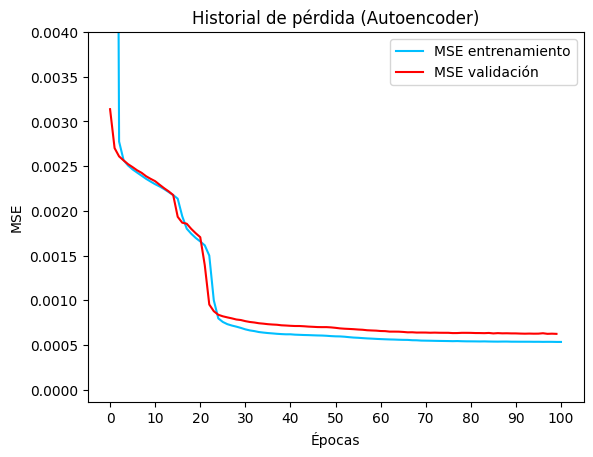

In [64]:
x=range(1,epochs+1)
plt.plot(x,history.history['loss'], label='MSE entrenamiento',color="deepskyblue")
plt.plot(history.history['val_loss'], label='MSE validación',color="red")
plt.xlabel('Épocas')
plt.ylabel('MSE')
plt.title('Historial de pérdida (Autoencoder)')
plt.ylim(top=0.004)
plt.legend()
plt.xticks(range(0,epochs+1,10))
plt.show()

In [65]:
# reconstrucciones del autoencoder
reconstructed = autoencoder.predict(X_test)

# MSE por fila
mse_list = np.mean((X_test - reconstructed)**2, axis=1) #Calculando error cuadratico medio


88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


In [66]:
percentil=95
umbral = np.percentile(mse_list.values, percentil)
print(f"Umbral (percentil {percentil}): {umbral:.4f}")


Umbral (percentil 95): 0.0017


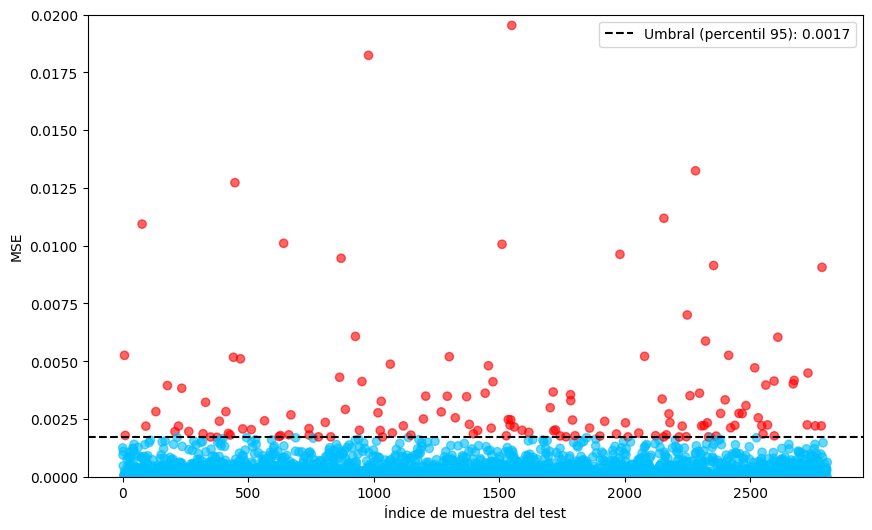

In [67]:
figsize=(10,6)

color = "deepskyblue"
df_mse = pd.DataFrame(mse_list, columns=["MSE"])
df_mse["Tipo"] = np.where(df_mse["MSE"] > umbral, "Anomalía", "Normal")

# Gráfico de dispersión
plt.figure(figsize=figsize)
plt.scatter(range(len(df_mse)), df_mse["MSE"], c=df_mse["Tipo"].map({"Normal": "deepskyblue", "Anomalía": "red"}), alpha=0.6)
plt.axhline(y=umbral, color='black', linestyle='--', label=f"Umbral (percentil {percentil}): {umbral:.4f}")
plt.ylim(bottom=0, top=0.02) # Para fines graficos se limita a 0.02
plt.xlabel("Índice de muestra del test")
plt.ylabel("MSE")
plt.legend()

In [68]:
X

,pl_orbper,pl_rade,pl_orbeccen,pl_eqt,st_mass,st_logg,sy_dist
110,0.000153,0.000423,0.066304,0.467047,0.232672,0.428029,0.001753
177,0.002270,0.000861,0.006272,0.121086,0.119068,0.420436,0.000924
188,0.005118,0.000526,0.003674,0.085165,0.119068,0.420436,0.000924
208,0.011372,0.000458,0.000000,0.107329,0.248778,0.436283,0.050067
233,0.001126,0.004978,0.071739,0.478002,0.377912,0.328986,0.168760
...,...,...,...,...,...,...,...
38958,0.001098,0.002921,0.000000,0.281584,0.271498,0.411522,0.078078
38972,0.000982,0.005355,0.000000,0.369984,0.395168,0.360350,0.066285
38976,0.000735,0.003530,0.041304,0.412274,0.376474,0.394355,0.065900
39066,0.001668,0.000418,0.000000,0.260439,0.265746,0.413173,0.003399


In [81]:
bottleneck_model = tf.keras.models.Model(
    inputs=autoencoder.input,
    outputs=autoencoder.get_layer("bottleneck").output
)

bottleneck_coords = bottleneck_model.predict(X)

df_norm[["AE1", "AE2"]] = bottleneck_coords
# Calculamos el MSE para cada muestra
mse_X = np.mean((X - autoencoder.predict(X))**2, axis=1)
# Agregamos el MSE al dataframe del bottleneck
df_norm ["MSE"] = mse_X

439/439 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
439/439 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


In [100]:
def anotar_top10(df,dfNombresplanetas,x_col="Bottleneck_1", y_col="Bottleneck_2",metric_col="MSE",angle=45):
    """
    Anota los top 10 puntos en el gráfico.
    """
    reverse = False if metric_col == "MSE" else True
    top10 = df.sort_values(by=metric_col, ascending=reverse).head(10)
    for idx in top10.index:
        x = df.loc[idx, x_col]
        y = df.loc[idx, y_col]
        nombre = dfNombresplanetas.loc[idx]   # nombre del planeta

        ann = plt.annotate(
            text=str(nombre),
            xy=(x, y),
            xytext=(3, 3),
            textcoords="offset points",
            color="black",
            fontsize=8,
            weight="bold",
            rotation=angle
        )

        # Contorno blanco
        ann.set_path_effects([
            path_effects.Stroke(linewidth=2, foreground='white'),
            path_effects.Normal()
        ])

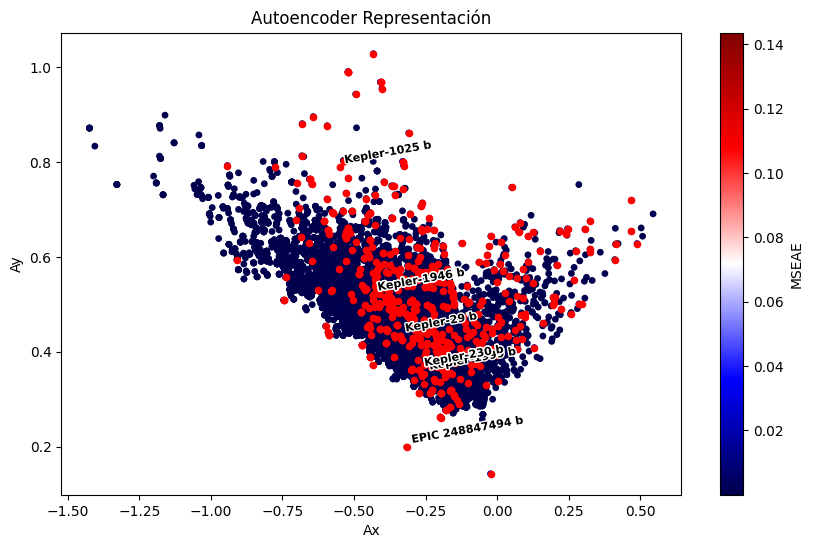

In [91]:
# Graficamos el bottleneck con los puntos coloreados según su MSE
plt.figure(figsize=(10, 6))
sc = plt.scatter(df_norm['AE1'], df_norm['AE2'],
                 c=df_norm['MSE'], s=15, cmap="seismic")

x_anomalia=df_norm[df_norm["MSE"]>umbral]["AE1"]
y_anomalia=df_norm[df_norm["MSE"]>umbral]["AE2"]
#plt.scatter(x_anomalia,y_anomalia,color="black",s=20)
# Resaltamos los puntos que superan el umbral
plt.scatter(x_anomalia, y_anomalia, color="red", s=20, label="Anomalías")
anotar_top10(df_norm, dfNombresplanetas, x_col="AE1", y_col="AE2", metric_col="MSE",angle=10)

plt.colorbar(sc, label="MSEAE")
plt.title("Autoencoder Representación")
plt.xlabel("Ax")
plt.ylabel("Ay")
plt.savefig("Imagenes/ReduccionDimensional/Autoencoder_Bottleneck.png",
            bbox_inches='tight', pad_inches=0.03)
plt.show()


## PCA

In [84]:
# Usamos PCA para reducir la dimensionalidad a 2D y graficar los datos
from sklearn.decomposition import PCA
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
# dataframe con los resultados de PCA
df_norm[["PCA_1", "PCA_2"]] = X_pca




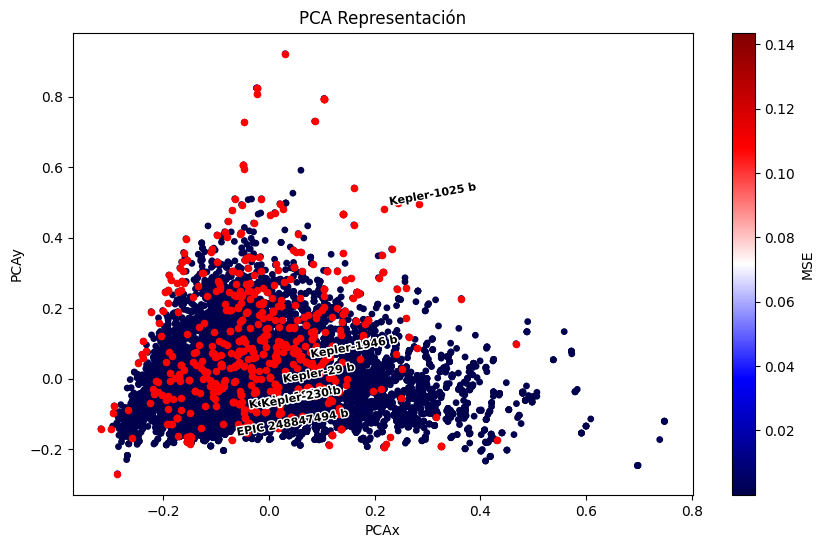

In [85]:
# Graficamos el PCA con los puntos coloreados según su MSE
plt.figure(figsize=(10, 6))
sc = plt.scatter(df_norm['PCA_1'], df_norm['PCA_2'],
                 c=df_norm['MSE'], s=15, cmap="seismic")

x_anomalia=df_norm[df_norm["MSE"]>umbral]["PCA_1"]
y_anomalia=df_norm[df_norm["MSE"]>umbral]["PCA_2"]
#plt.scatter(x_anomalia,y_anomalia,color="black",s=20)
# Resaltamos los puntos que superan el umbral
plt.scatter(x_anomalia, y_anomalia,  color="red", s=20, label="Anomalías")
anotar_top10(df_norm, dfNombresplanetas, x_col="PCA_1", y_col="PCA_2", metric_col="MSE",angle=10)

plt.colorbar(sc, label="MSE")
plt.title("PCA Representación")
plt.xlabel("PCAx")
plt.ylabel("PCAy")
plt.savefig("Imagenes/ReduccionDimensional/PCA_Test_Autoencoder.png",
            bbox_inches='tight', pad_inches=0.03)
plt.show()


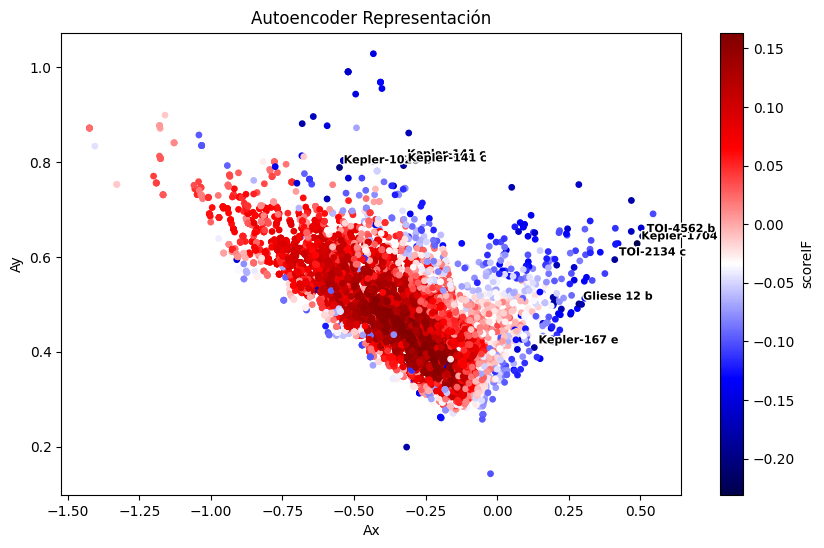

In [107]:
# Representacion Autoencoder con scoreIF
plt.figure(figsize=(10, 6))
sc = plt.scatter(df_norm['AE1'], df_norm['AE2'],
                 c=df_norm['scoreIF'], s=15, cmap="seismic")



anotar_top10(df_norm, dfNombresplanetas, x_col="AE1", y_col="AE2", metric_col="scoreIF",angle=0)

plt.colorbar(sc, label="scoreIF")
plt.title("Autoencoder Representación")
plt.xlabel("Ax")
plt.ylabel("Ay")
plt.savefig("Imagenes/ReduccionDimensional/Autoencoder_Test_scoreIF.png",
            bbox_inches='tight', pad_inches=0.03)
plt.show()

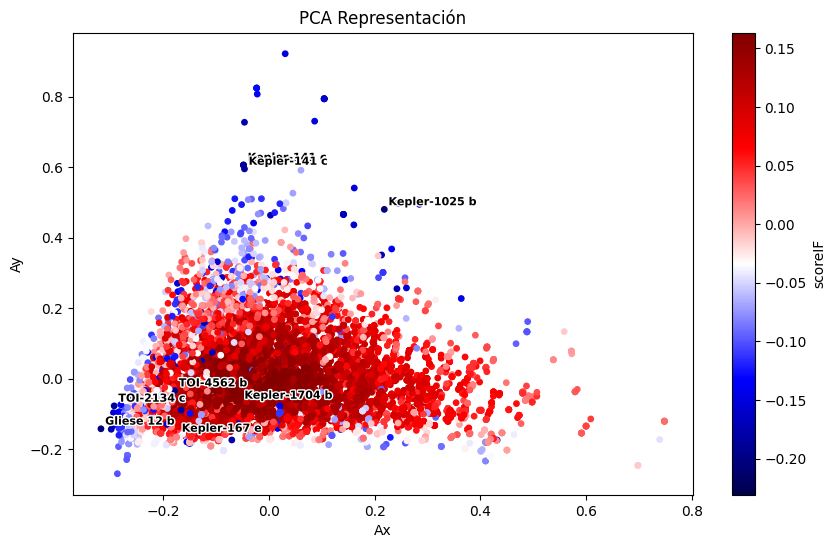

In [108]:
# Representacion PCA con scoreIF

plt.figure(figsize=(10, 6))
sc = plt.scatter(df_norm['PCA_1'], df_norm['PCA_2'],
                 c=df_norm['scoreIF'], s=15, cmap="seismic")



anotar_top10(df_norm, dfNombresplanetas, x_col="PCA_1", y_col="PCA_2", metric_col="scoreIF",angle=0)

plt.colorbar(sc, label="scoreIF")
plt.title("PCA Representación")
plt.xlabel("Ax")
plt.ylabel("Ay")
plt.savefig("Imagenes/ReduccionDimensional/PCA_Test_scoreIF.png",
            bbox_inches='tight', pad_inches=0.03)

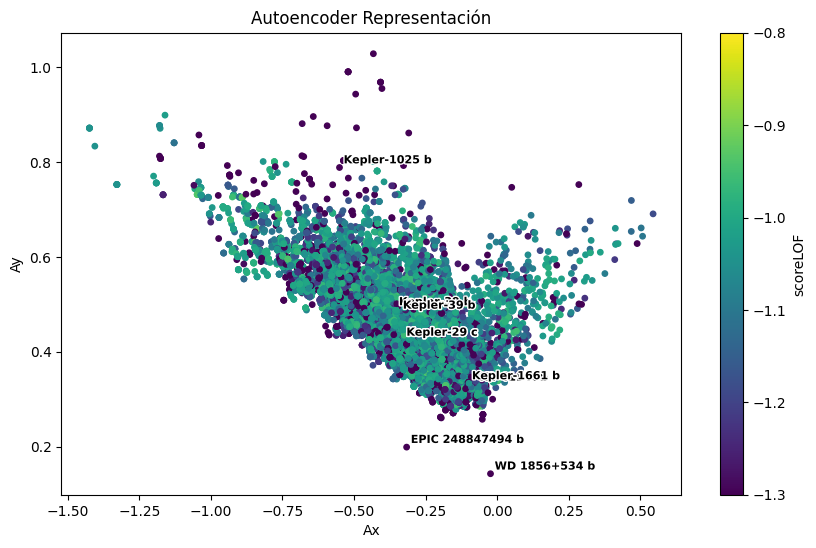

In [ ]:
# Representacion Autoencoder con scoreLOF

plt.figure(figsize=(10, 6))
sc = plt.scatter(df_norm['AE1'], df_norm['AE2'],
                 c=df_norm['scoreLOF'], s=15, cmap="viridis",vmin=-1.3,vmax=-0.8)



anotar_top10(df_norm, dfNombresplanetas, x_col="AE1", y_col="AE2", metric_col="scoreLOF",angle=0)

plt.colorbar(sc, label="scoreLOF")
plt.title("Autoencoder Representación")
plt.xlabel("Ax")
plt.ylabel("Ay")
plt.savefig("Imagenes/ReduccionDimensional/Autoencoder_Test_scoreLOF.png",
            bbox_inches='tight', pad_inches=0.03)

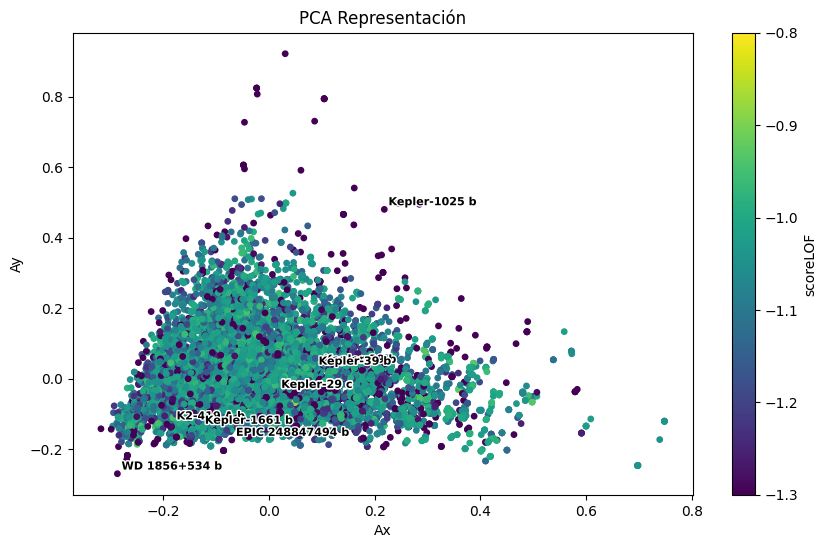

In [127]:
# Representacion PCA con scoreLOF

plt.figure(figsize=(10, 6))
sc = plt.scatter(df_norm['PCA_1'], df_norm['PCA_2'],
                 c=df_norm['scoreLOF'], s=15, cmap="viridis",vmin=-1.3,vmax=-0.8)



anotar_top10(df_norm, dfNombresplanetas, x_col="PCA_1", y_col="PCA_2", metric_col="scoreLOF",angle=0)

plt.colorbar(sc, label="scoreLOF")
plt.title("PCA Representación")
plt.xlabel("Ax")
plt.ylabel("Ay")
plt.savefig("Imagenes/ReduccionDimensional/PCA_Test_scoreLOF.png",
            bbox_inches='tight', pad_inches=0.03)